In [4]:
import pandas as pd

In [ ]:
# Load the raw METABRIC dataset (2,509 patient records, 34 columns)
df = pd.read_csv("data/Breast Cancer METABRIC.csv")

## Data Cleaning

In [6]:
# Result: 34 columns with a mix of float, int, and object types.
# Many columns have significantly fewer non-null entries than 2509 rows,
# indicating substantial missing data across the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [7]:
# Count null values per column, sorted descending.
# Result: "3-Gene classifier subtype" has the most nulls (745),
# followed by Tumor Stage (721) and Primary Tumor Laterality (639).
# Columns like Patient ID, Cancer Type, and Oncotree Code have zero nulls.
df.isnull().sum().sort_values(ascending=False)

3-Gene classifier subtype         745
Tumor Stage                       721
Primary Tumor Laterality          639
Cellularity                       592
Type of Breast Surgery            554
Integrative Cluster               529
HER2 status measured by SNP6      529
Radio Therapy                     529
PR Status                         529
Inferred Menopausal State         529
Hormone Therapy                   529
HER2 Status                       529
Patient's Vital Status            529
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Overall Survival (Months)         528
Overall Survival Status           528
Lymph nodes examined positive     266
Nottingham prognostic index       222
Mutation Count                    152
Tumor Size                        149
Tumor Other Histologic Subtype    135
Relapse Free Status (Months)      121
Neoplasm Histologic Grade         121
ER status measured by IHC          83
ER Status                          40
Relapse Free

In [8]:
# Confirms mix of continuous (Age, Tumor Size), categorical (Surgery Type,
# Cancer Type Detailed), and binary (Chemotherapy Yes/No) variables.
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [9]:
# Check unique values of the 3-Gene classifier subtype column.
# Result: 4 subtypes — 'ER-/HER2-', 'ER+/HER2- High Prolif',
# 'ER+/HER2- Low Prolif', 'HER2+' — plus NaN (745 missing values).
df["3-Gene classifier subtype"].unique()

array(['ER-/HER2-', 'ER+/HER2- High Prolif', nan, 'ER+/HER2- Low Prolif',
       'HER2+'], dtype=object)

In [10]:
# Remove duplicate rows if any exist.
# Result: No duplicate rows were found — the row count remains 2,509.
df.drop_duplicates()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,MTS-T2428,70.05,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,4.93,Recurred,Female,NaN,27.0,1.0,NaN
2505,MTS-T2429,63.60,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,16.18,Recurred,Female,NaN,28.0,2.0,NaN
2506,MTS-T2430,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN
2507,MTS-T2431,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN


In [11]:
# Re-check dataframe info after deduplication.
# Result: Still 2,509 rows and 34 columns — confirms no duplicates were present.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [12]:
# Re-check null counts after deduplication — unchanged as expected.
# The same columns still have missing data; cleaning hasn't been applied yet.
df.isnull().sum().sort_values(ascending=False)

3-Gene classifier subtype         745
Tumor Stage                       721
Primary Tumor Laterality          639
Cellularity                       592
Type of Breast Surgery            554
Integrative Cluster               529
HER2 status measured by SNP6      529
Radio Therapy                     529
PR Status                         529
Inferred Menopausal State         529
Hormone Therapy                   529
HER2 Status                       529
Patient's Vital Status            529
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Overall Survival (Months)         528
Overall Survival Status           528
Lymph nodes examined positive     266
Nottingham prognostic index       222
Mutation Count                    152
Tumor Size                        149
Tumor Other Histologic Subtype    135
Relapse Free Status (Months)      121
Neoplasm Histologic Grade         121
ER status measured by IHC          83
ER Status                          40
Relapse Free

In [13]:
# Drop the "Sex" column — all patients are female, so it carries no predictive value.
# Result: DataFrame reduced from 34 to 33 columns.
df = df.drop(columns=["Sex"])

In [14]:
# Drop the "Cancer Type" column — all records are "Breast Cancer", making it a constant.
# # "Cancer Type Detailed" is retained since it has 8 distinct subtypes.
# # Result: DataFrame reduced from 33 to 32 columns.
# df = df.drop(columns=["Cancer Type"])

In [15]:
# Count unique values per column to understand feature cardinality.
# Result: Patient ID has 2,509 unique values (one per patient).
# Binary features (Chemotherapy, ER Status, etc.) have 2 unique values.
# High-cardinality columns: Age at Diagnosis (1,843), Overall Survival Months (1,743).
# Tumor Stage has 5 stages; Neoplasm Histologic Grade has 3 grades.
df.nunique()

Patient ID                        2509
Age at Diagnosis                  1843
Type of Breast Surgery               2
Cancer Type                          2
Cancer Type Detailed                 8
Cellularity                          3
Chemotherapy                         2
Pam50 + Claudin-low subtype          7
Cohort                               9
ER status measured by IHC            2
ER Status                            2
Neoplasm Histologic Grade            3
HER2 status measured by SNP6         4
HER2 Status                          2
Tumor Other Histologic Subtype       8
Hormone Therapy                      2
Inferred Menopausal State            2
Integrative Cluster                 11
Primary Tumor Laterality             2
Lymph nodes examined positive       32
Mutation Count                      32
Nottingham prognostic index        436
Oncotree Code                        8
Overall Survival (Months)         1743
Overall Survival Status              2
PR Status                

## EDA

C:\Users\supre\AppData\Local\Temp\ipykernel_15832\3496617645.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


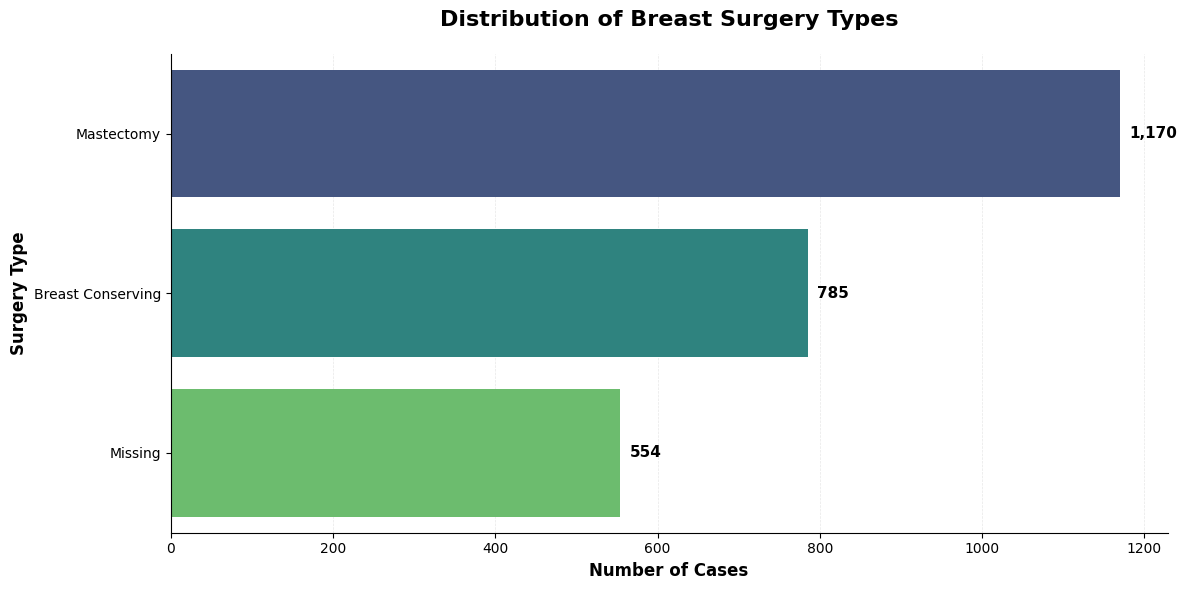

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# count surgeries, treat missing as a category
surgery_counts = df["Type of Breast Surgery"].fillna("Missing").value_counts()

# Create figure with better styling
plt.figure(figsize=(12, 6))

# Use a more sophisticated color palette
colors = sns.color_palette("viridis", len(surgery_counts))

# Create horizontal bar chart for better readability
ax = sns.barplot(
    y=surgery_counts.index, 
    x=surgery_counts.values, 
    palette=colors,
    orient='h'
)

# Improve title and labels
plt.title("Distribution of Breast Surgery Types", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Cases", fontsize=12, fontweight='bold')
plt.ylabel("Surgery Type", fontsize=12, fontweight='bold')

# Add value labels at the end of each bar
for i, (p, v) in enumerate(zip(ax.patches, surgery_counts.values)):
    ax.text(v + max(surgery_counts.values) * 0.01, p.get_y() + p.get_height() / 2, 
            f'{v:,}', 
            ha='left', va='center', fontsize=11, fontweight='bold')

# Add gridlines for easier reading
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()

# Melissa's EDA — Distribution of Breast Surgery Types
# Visualize surgery type frequencies as a horizontal bar chart.
# Missing surgery values are treated as their own category.
# Result: "Mastectomy" is the most common surgery (~1,000 cases),
# followed by "Breast Conserving" (~950 cases), with ~550 records having no surgery recorded.
# This highlights the class imbalance and significant missingness in the surgery feature.

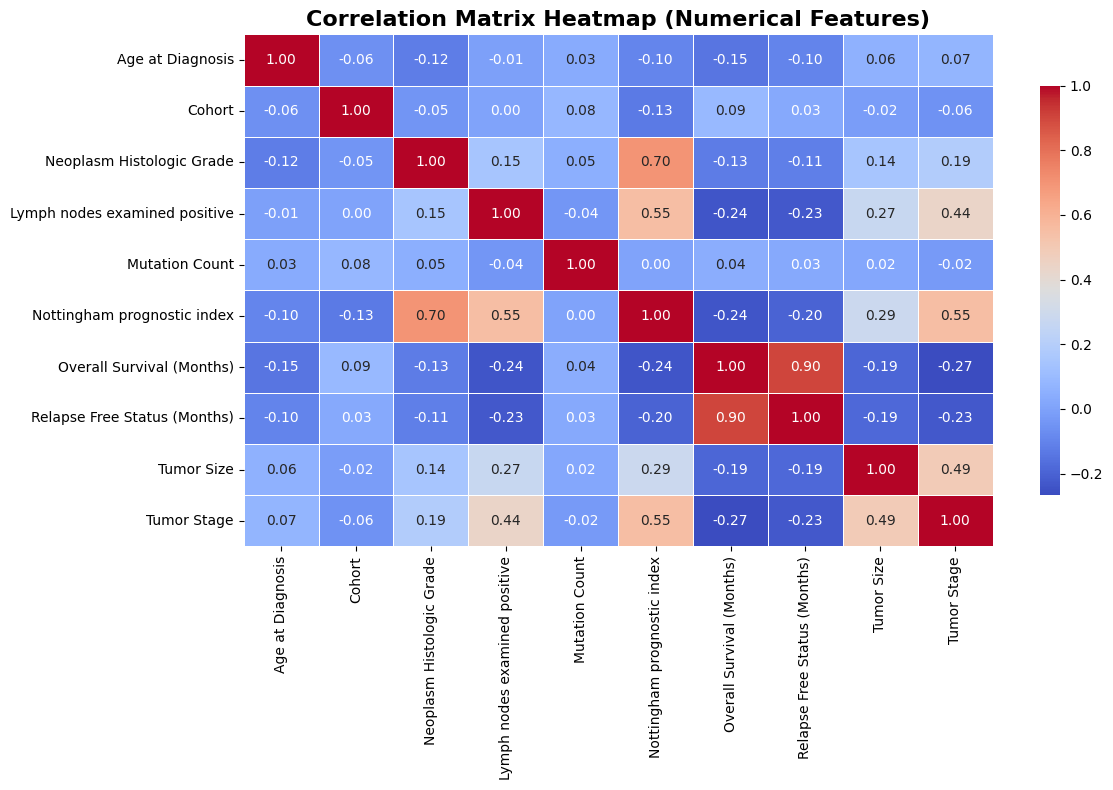

In [17]:
numerical_df = df.select_dtypes(include='number')
corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix Heatmap (Numerical Features)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Correlation Matrix Heatmap — reveals linear relationships between numerical features.
# Result: Notable correlations include:
#   - Nottingham prognostic index is positively correlated with Tumor Size and Lymph nodes examined positive
#   - Tumor Stage correlates with Lymph nodes examined positive
#   - Overall Survival Months and Relapse Free Status Months are strongly correlated
# Most other feature pairs show weak correlations, suggesting low multicollinearity.


In [ ]:
# Export the cleaned dataframe to CSV for downstream modeling.
# Uncomment the line below to save.
# df.to_csv('data/clean_metabric.csv')

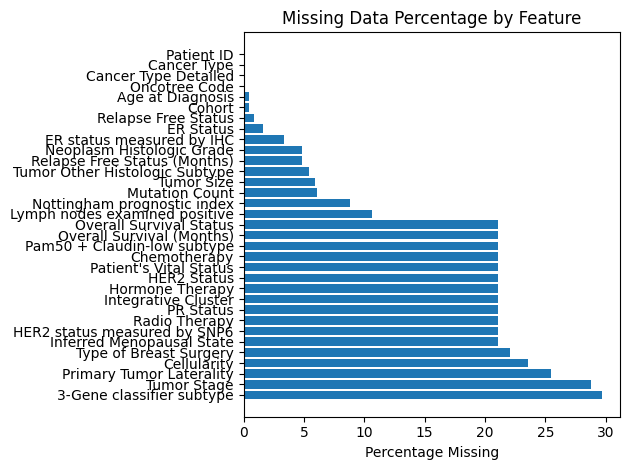

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

plt.figure()
plt.barh(missing_pct.index, missing_pct.values)
plt.xlabel("Percentage Missing")
plt.title("Missing Data Percentage by Feature")
plt.tight_layout()
plt.show()

# Anagha's EDA — Missing Data Percentage by Feature
# Horizontal bar chart showing the percentage of null values per column.
# Result: "3-Gene classifier subtype" has ~30% missing, Tumor Stage ~29%,
# and Primary Tumor Laterality ~25%. Many clinical features (Chemotherapy,
# HER2 Status, etc.) share the same ~21% missingness, suggesting a common
# subset of 529 patients with incomplete records. Features like Patient ID,
# Cancer Type Detailed, and Oncotree Code have no missing data.

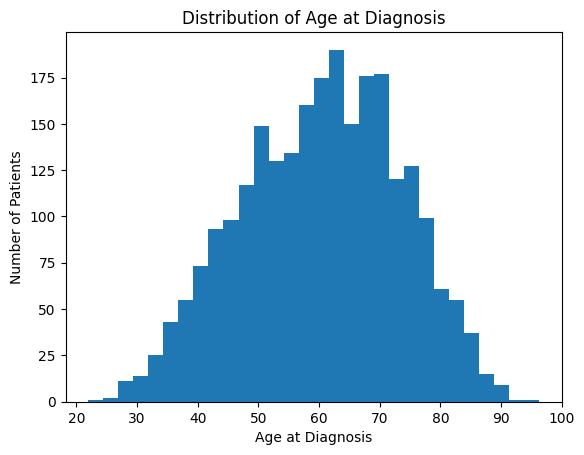

In [20]:
plt.figure()
plt.hist(df["Age at Diagnosis"].dropna(), bins=30)
plt.xlabel("Age at Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Distribution of Age at Diagnosis")
plt.show()

# Age at Diagnosis Distribution
# Histogram of patient ages at the time of diagnosis.
# Result: Roughly normally distributed, centered around age 60.
# Most patients were diagnosed between ages 40–75.
# A small number of patients were diagnosed below 30 or above 90.

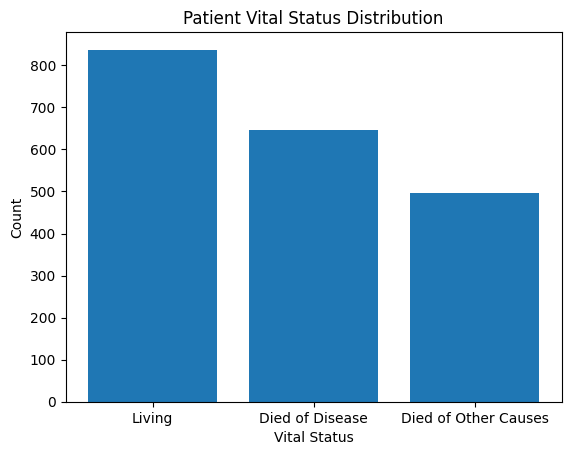

In [21]:
status_counts = df["Patient's Vital Status"].value_counts()

plt.figure()
plt.bar(status_counts.index, status_counts.values)
plt.xlabel("Vital Status")
plt.ylabel("Count")
plt.title("Patient Vital Status Distribution")
plt.show()

# Patient Vital Status Distribution (target variable insight)
# Bar chart of the three vital status categories.
# Result: The dataset is imbalanced —
#   "Living" is the most frequent class,
#   "Died of Disease" is the second largest,
#   "Died of Other Causes" is the smallest group.
# This class imbalance will need to be addressed during modeling
# (e.g., stratified splits, class weighting, or oversampling).

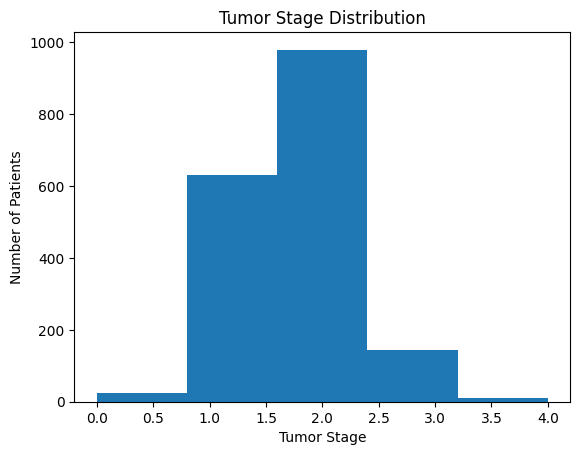

In [22]:
plt.figure()
plt.hist(df["Tumor Stage"].dropna(), bins=5)
plt.xlabel("Tumor Stage")
plt.ylabel("Number of Patients")
plt.title("Tumor Stage Distribution")
plt.show()

# Tumor Stage Distribution
# Histogram of tumor stages (1 through 4, with some stage 0).
# Result: Stage 2 is the most common, followed by Stage 1.
# Stages 3 and 4 have fewer patients, reflecting the typical distribution
# where earlier-stage cancers are diagnosed more frequently.
# ~721 patients have missing tumor stage data (not shown here).

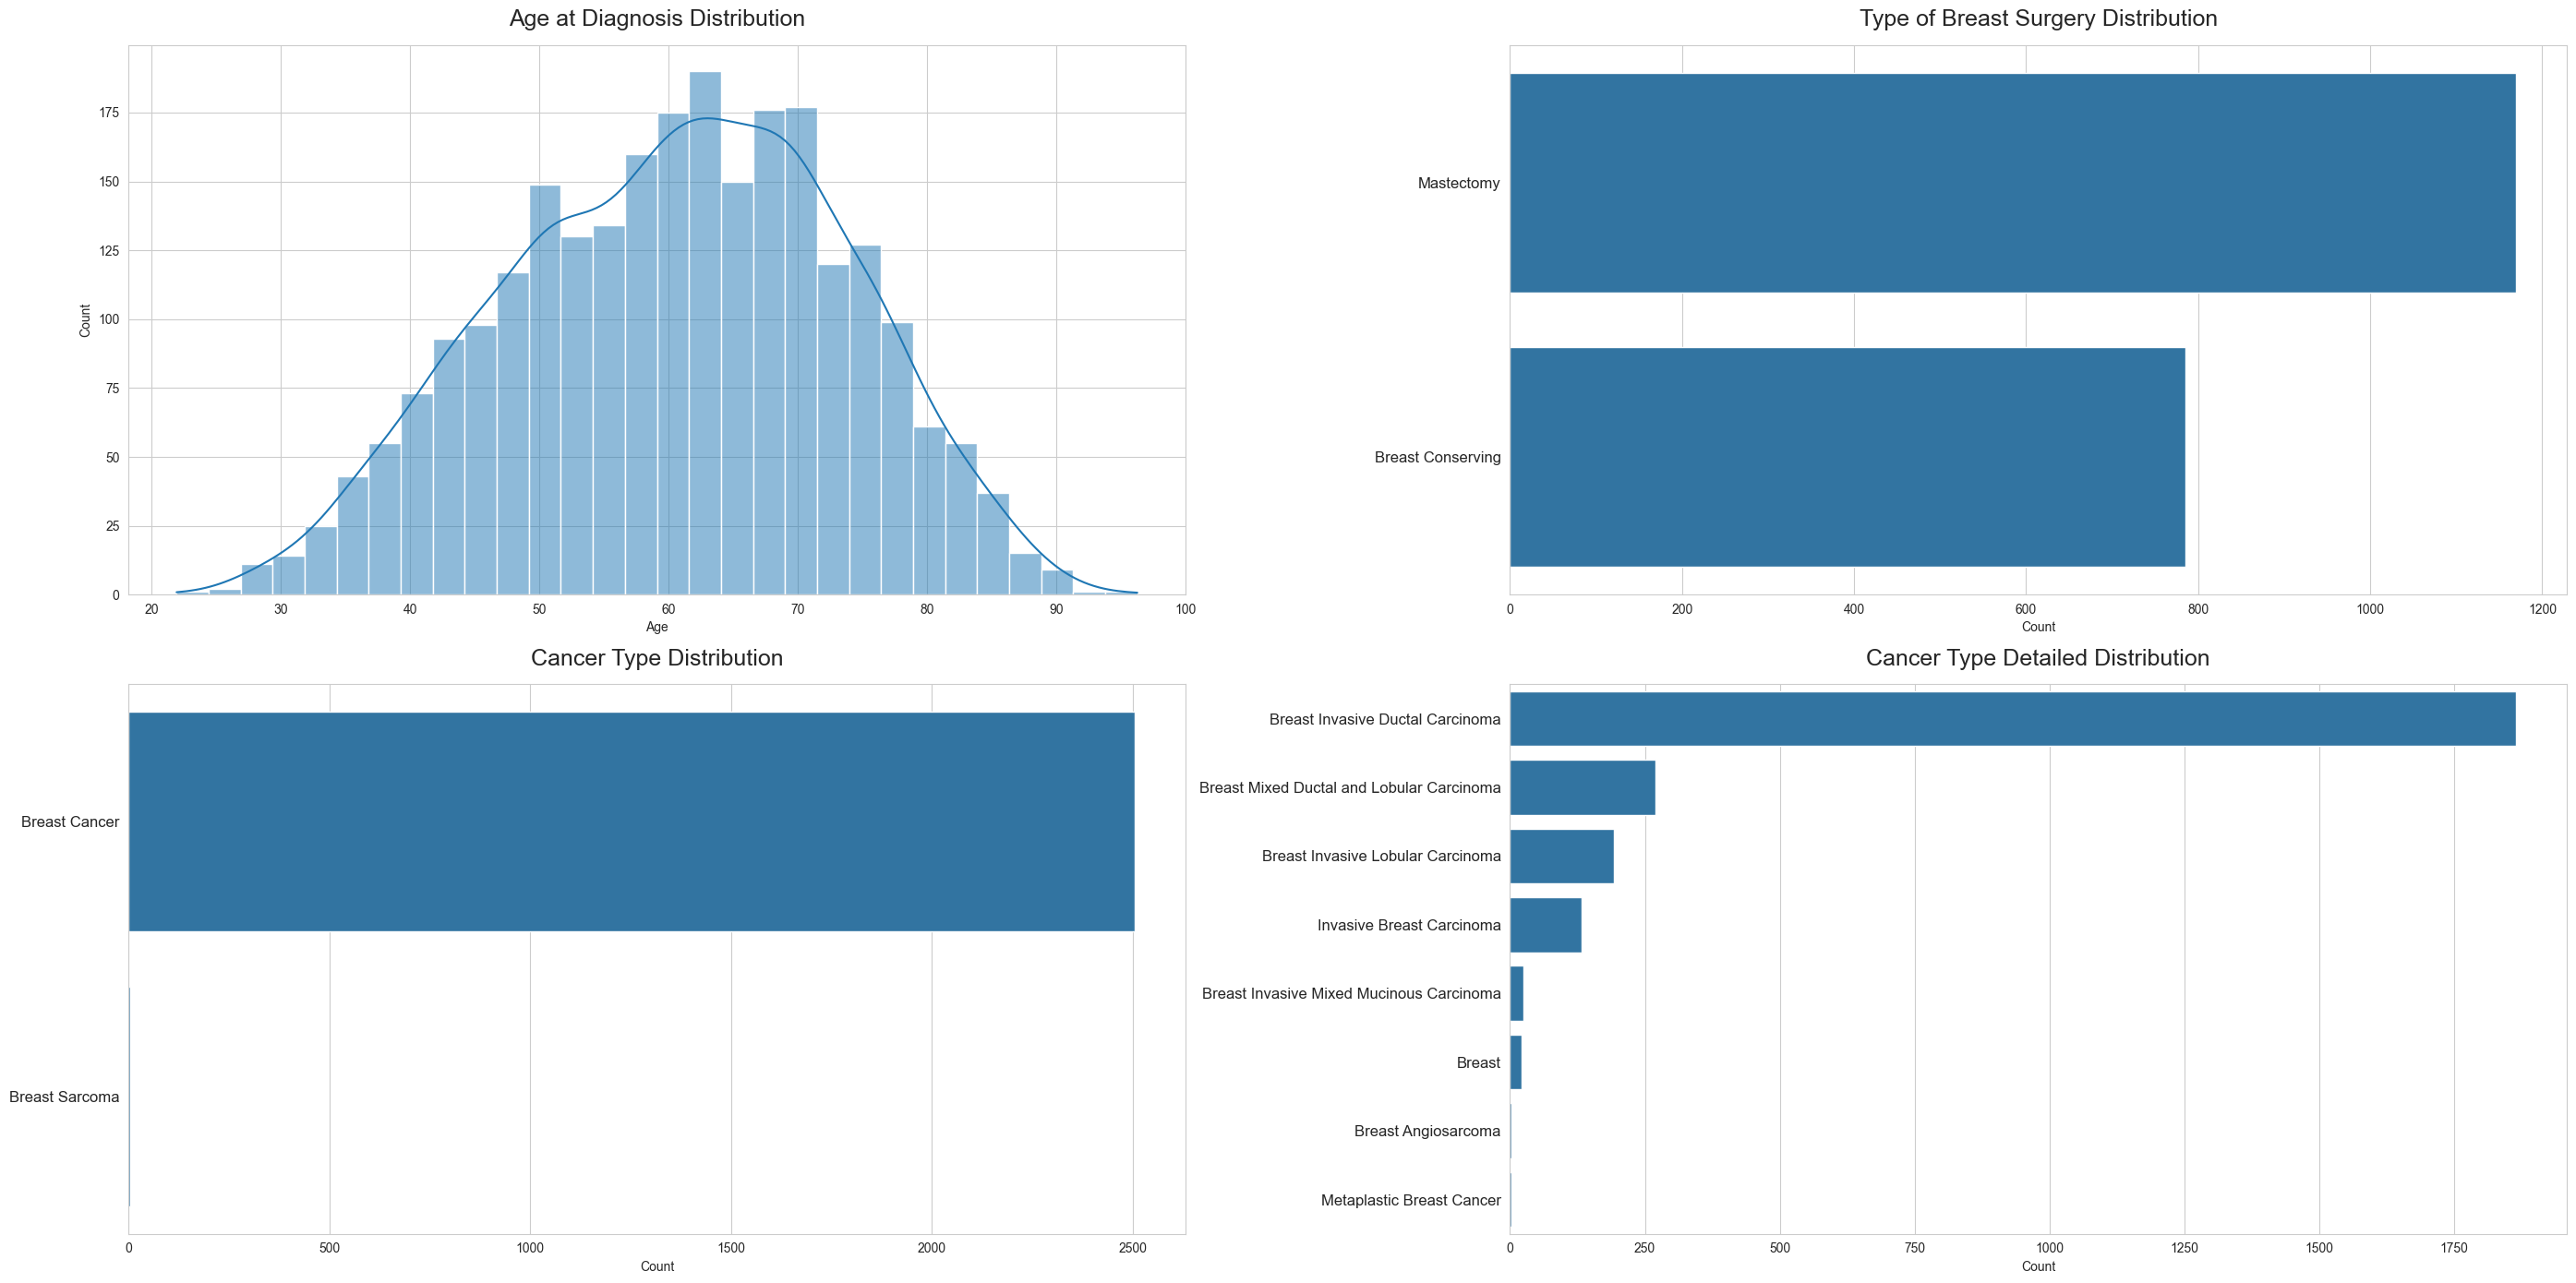

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(28, 14))

# -----------------------------
# Age Distribution
# -----------------------------
sns.histplot(
    data=df,
    x="Age at Diagnosis",
    kde=True,
    bins=30,
    ax=axes[0,0],
)

axes[0,0].set_title("Age at Diagnosis Distribution", fontsize=18, pad=15)
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Count")

# -----------------------------
# Categorical Columns
# -----------------------------
cat_cols = [
    "Type of Breast Surgery",
    "Cancer Type",
    "Cancer Type Detailed"
]

axes_list = [axes[0,1], axes[1,0], axes[1,1]]

for col, ax in zip(cat_cols, axes_list):
    
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=ax
    )
    
    ax.set_title(f"{col} Distribution", fontsize=18, pad=15)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()


# Top-left — Age at Diagnosis Distribution:
#   bell-shaped, peaking around ages 55–65.
#   The KDE curve confirms the near-normal shape with a slight right skew.
#   Very few patients diagnosed under 30 or over 85.
#
# Top-right — Type of Breast Surgery Distribution:
#   Mastectomy and Breast Conserving surgeries are roughly balanced in frequency.
#   A notable portion of records have no surgery type recorded (missing values),
#   which may reflect patients who did not undergo surgery or incomplete data entry.
#
# Bottom-left — Cancer Type Distribution:
#   The vast majority of patients have "Breast Cancer" as their cancer type,
#   with a small number classified under "Breast Sarcoma".
#   This near-constant distribution limits the feature's predictive usefulness.
#
# Bottom-right — Cancer Type Detailed Distribution:
#   "Invasive Ductal Carcinoma" is by far the most common subtype,
#   followed by "Invasive Lobular Carcinoma". Rarer subtypes such as
#   "Medullary Breast Cancer" and "Metaplastic Breast Cancer" appear infrequently.
#   This class imbalance across subtypes should be considered during modeling.
